In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')


In [2]:
X_train = np.load("../data/processed/X_train_balanced.npy")
y_train = np.load("../data/processed/y_train_balanced.npy")
X_test = np.load("../data/processed/X_test_scaled.npy")
y_test = np.load("../data/processed/y_test.npy")

with open("../data/processed/feature_names.txt", "r") as f:
    feature_names = [line.strip() for line in f.readlines()]

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (10167052, 13)
Test data shape: (1272524, 13)


In [3]:
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)  # stump
model = AdaBoostClassifier(estimator=base_estimator, n_estimators=50, random_state=42)
model.fit(X_train, y_train)
print("AdaBoost training completed.")

KeyboardInterrupt: 

In [4]:
sample_size = 200000  # You can reduce to 100,000 for even faster training
if X_train.shape[0] > sample_size:
    np.random.seed(42)
    indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
    X_train_sub = X_train[indices]
    y_train_sub = y_train[indices]
    print(f"Using subsampled training set: {X_train_sub.shape}")
else:
    X_train_sub = X_train
    y_train_sub = y_train
    print("Using full training set (already small enough)")

Using subsampled training set: (200000, 13)


In [5]:
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)
model = AdaBoostClassifier(estimator=base_estimator, n_estimators=20, random_state=42)
model.fit(X_train_sub, y_train_sub)
print("✅ AdaBoost training completed (on subsampled data).")


✅ AdaBoost training completed (on subsampled data).


In [6]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))

=== Classification Report ===
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.99      1.00   1270881
       Fraud       0.13      1.00      0.23      1643

    accuracy                           0.99   1272524
   macro avg       0.57      0.99      0.61   1272524
weighted avg       1.00      0.99      0.99   1272524



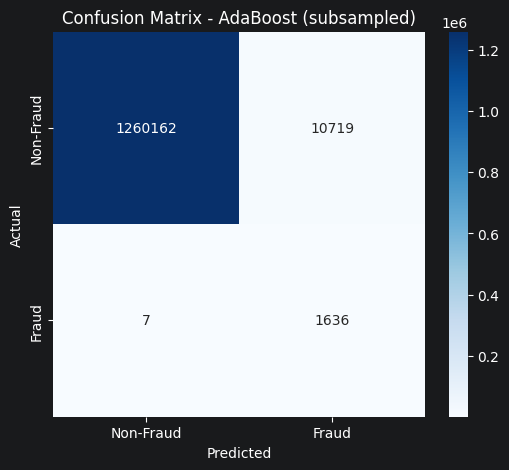

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix - AdaBoost (subsampled)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("../data/processed/cm_adaboost.png")
plt.show()


In [8]:
roc_auc = roc_auc_score(y_test, y_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")


ROC-AUC Score: 0.9998


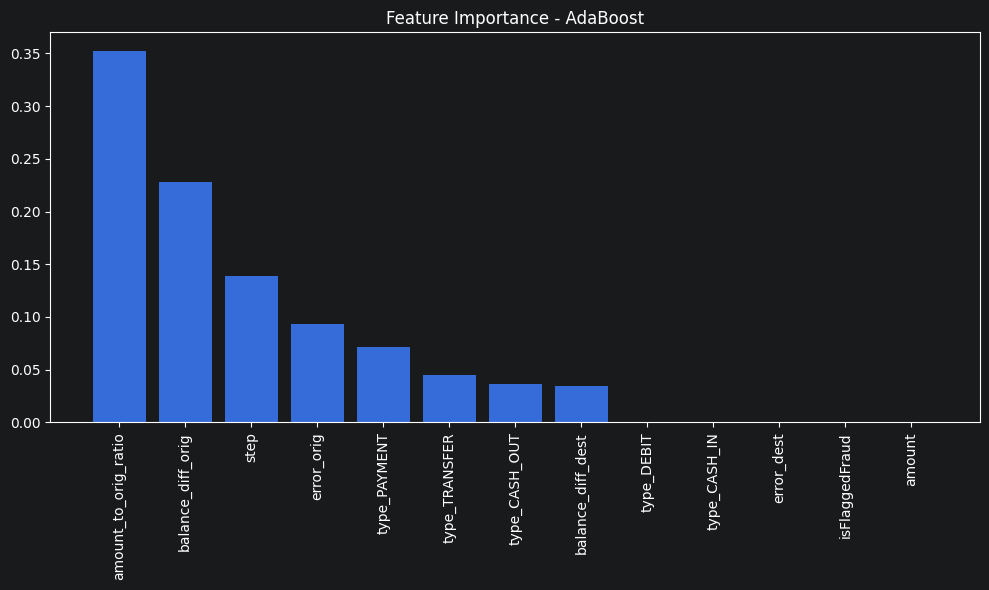


Top 10 most important features:
1. amount_to_orig_ratio (importance: 0.3524)
2. balance_diff_orig (importance: 0.2282)
3. step (importance: 0.1393)
4. error_orig (importance: 0.0929)
5. type_PAYMENT (importance: 0.0715)
6. type_TRANSFER (importance: 0.0445)
7. type_CASH_OUT (importance: 0.0365)
8. balance_diff_dest (importance: 0.0346)
9. type_DEBIT (importance: 0.0000)
10. type_CASH_IN (importance: 0.0000)


In [9]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.title('Feature Importance - AdaBoost')
plt.tight_layout()
plt.savefig("../data/processed/feature_importance_adaboost.png")
plt.show()

print("\nTop 10 most important features:")
for i in range(10):
    print(f"{i+1}. {feature_names[indices[i]]} (importance: {importances[indices[i]]:.4f})")

In [10]:
joblib.dump(model, "../models/adaboost.pkl")
print("✅ Model saved as ../models/adaboost.pkl")

✅ Model saved as ../models/adaboost.pkl
